In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model = "models/gemini-3.1-flash-lite-preview")

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [27]:
def generate_joke(state: JokeState):

    topic = state["topic"]

    prompt = f"generate a joke on the topic: {topic} "

    response = model.invoke(prompt).content

    return { "joke" : response }

In [28]:
def generate_explanation(state: JokeState):

    joke = state['joke']

    prompt = f" write a explain for the joke: {joke}"

    response = model.invoke(prompt).content

    return { "explanation": response }

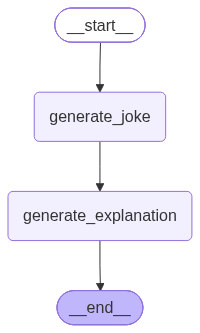

In [29]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()

graph.compile(checkpointer = checkpointer)

In [30]:
workflow = graph.compile(checkpointer = checkpointer)

In [33]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the pizza maker go into business?\n\nBecause he wanted to make some **dough**!',
   'extras': {'signature': 'EnEKbwERTTIPdENNC5Fu4z/UZepJGaxAFXvEN6SoUOggcMdaClPpW8KkDg3xnU/97GS4KR3dbOm+FjIBYyV07N1DVWuzsg3wirdMbh/h8wszw+o4Z8JSOkxdj4ElB/ENGV+zSTNF4jxuX21Z2GHjZY3huA=='}}],
 'explanation': [{'type': 'text',
   'text': 'The joke relies on a **pun** (a play on words) involving the word "dough."\n\nHere is the breakdown:\n\n1.  **Literal Meaning:** In the context of a pizza maker, "dough" refers to the mixture of flour, water, and yeast used to create the base of the pizza.\n2.  **Slang Meaning:** In general business and money contexts, "dough" is a common slang term for **money**.\n\n**The Humor:**\nThe joke sets you up to think about the literal act of making pizza, but the punchline uses the slang meaning to suggest the pizza maker started the business simply to make money (profit). The humor comes from the double meaning of

In [34]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the pizza maker go into business?\n\nBecause he wanted to make some **dough**!', 'extras': {'signature': 'EnEKbwERTTIPdENNC5Fu4z/UZepJGaxAFXvEN6SoUOggcMdaClPpW8KkDg3xnU/97GS4KR3dbOm+FjIBYyV07N1DVWuzsg3wirdMbh/h8wszw+o4Z8JSOkxdj4ElB/ENGV+zSTNF4jxuX21Z2GHjZY3huA=='}}], 'explanation': [{'type': 'text', 'text': 'The joke relies on a **pun** (a play on words) involving the word "dough."\n\nHere is the breakdown:\n\n1.  **Literal Meaning:** In the context of a pizza maker, "dough" refers to the mixture of flour, water, and yeast used to create the base of the pizza.\n2.  **Slang Meaning:** In general business and money contexts, "dough" is a common slang term for **money**.\n\n**The Humor:**\nThe joke sets you up to think about the literal act of making pizza, but the punchline uses the slang meaning to suggest the pizza maker started the business simply to make money (profit). The humor comes from the double 

In [35]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the pizza maker go into business?\n\nBecause he wanted to make some **dough**!', 'extras': {'signature': 'EnEKbwERTTIPdENNC5Fu4z/UZepJGaxAFXvEN6SoUOggcMdaClPpW8KkDg3xnU/97GS4KR3dbOm+FjIBYyV07N1DVWuzsg3wirdMbh/h8wszw+o4Z8JSOkxdj4ElB/ENGV+zSTNF4jxuX21Z2GHjZY3huA=='}}], 'explanation': [{'type': 'text', 'text': 'The joke relies on a **pun** (a play on words) involving the word "dough."\n\nHere is the breakdown:\n\n1.  **Literal Meaning:** In the context of a pizza maker, "dough" refers to the mixture of flour, water, and yeast used to create the base of the pizza.\n2.  **Slang Meaning:** In general business and money contexts, "dough" is a common slang term for **money**.\n\n**The Humor:**\nThe joke sets you up to think about the literal act of making pizza, but the punchline uses the slang meaning to suggest the pizza maker started the business simply to make money (profit). The humor comes from the double

In [36]:
config1 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config1)

{'topic': 'pasta',
 'joke': [{'type': 'text',
   'text': 'Why did the pasta go to the doctor?\n\nBecause it was feeling **fusilli**.',
   'extras': {'signature': 'EnEKbwERTTIPZ6i8QYxIoU7U8rQC2LCpC4lJRZXvjDZgKub+aFyEvpINxavSrGUBiAwSmxLvyQWjFapAf7I8rjbO6G6PGlYyoK4rX+P480PMakA/ZpKm1+im/UU7RymlSIecRMjt478m1g2YJ/RfyPEvRw=='}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on a **pun**, which is a play on words that sound similar but have different meanings.\n\nHere is the breakdown:\n\n1.  **The Play on Words:** The word **"fusilli"** is a type of spiral-shaped Italian pasta. It sounds almost identical to the word **"silly."**\n2.  **The Context:** When someone says they are "feeling silly," it usually means they are acting goofy or behaving in a lighthearted, playful way.\n3.  **The Punchline:** By swapping "silly" with the pasta name "fusilli," the joke creates a double meaning. The pasta is "feeling fusilli" (a play on words for "feeling silly"), which is why it went to